In [ ]:
!pip install imbalanced-learn

## Phase 4 - Model Training & Comparison

### Step 1: Load Phase 3 outputs

In [1]:
# ── Phase 4: Model Training & Comparison ─────────────────────────────────────
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, recall_score,
                             precision_score)

# Load the split data from Phase 3
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()  # squeeze → Series
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("y_train churn rate:", f"{y_train.mean()*100:.1f}%")

X_train shape: (5625, 34)
y_train churn rate: 26.6%


### Step 2: Apply SMOTE — on training data only

In [3]:
# Apply SMOTE to fix class imbalance
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE:  {0: 4130, 1: 4130}


### Step 3: Define all four models

In [4]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',  # extra safety net on top of SMOTE
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1           # use all CPU cores
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        scale_pos_weight=3, # tells XGBoost minority class is 3x more important
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    )
}

### Step 4: Train all models and collect results

In [5]:
# --- Train every model and evaluate on the test set ---
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train on the SMOTE-balanced training data
    model.fit(X_train_sm, y_train_sm)
    
    # Predict on the UNTOUCHED test set
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # probability of churn

    # Collect all key metrics
    results[name] = {
        'Accuracy':  round((y_pred == y_test).mean() * 100, 1),
        'Precision': round(precision_score(y_test, y_pred) * 100, 1),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 1),
        'F1 Score':  round(f1_score(y_test, y_pred) * 100, 1),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 3),
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }
    print(f"  F1: {results[name]['F1 Score']}%  |  AUC: {results[name]['ROC-AUC']}\n")

Training Logistic Regression...
  F1: 58.9%  |  AUC: 0.82

Training Random Forest...
  F1: 58.5%  |  AUC: 0.808

Training XGBoost...
  F1: 60.3%  |  AUC: 0.807

Training KNN...
  F1: 56.6%  |  AUC: 0.772



### Step 5: Print the full comparison table

In [6]:
# --- Side-by-side comparison ---
print("=" * 65)
print(f"{'Model':<22} {'Accuracy':>8} {'Precision':>9} {'Recall':>7} {'F1':>7} {'AUC':>7}")
print("=" * 65)

for name, r in results.items():
    print(f"{name:<22} {r['Accuracy']:>7}%  {r['Precision']:>8}%  "
          f"{r['Recall']:>6}%  {r['F1 Score']:>6}%  {r['ROC-AUC']:>7}")

print("=" * 65)
print("\nRemember: for churn prediction, Recall and F1 matter most.")
print("Missing a churner (false negative) costs more than a false alarm.")

Model                  Accuracy Precision  Recall      F1     AUC
Logistic Regression       75.1%      52.4%    67.4%    58.9%     0.82
Random Forest             76.5%      55.1%    62.3%    58.5%    0.808
XGBoost                   73.4%      50.0%    75.9%    60.3%    0.807
KNN                       71.6%      47.7%    69.5%    56.6%    0.772

Remember: for churn prediction, Recall and F1 matter most.
Missing a churner (false negative) costs more than a false alarm.


### Step 6: Print the full classification report for your best model

In [7]:
# --- Detailed report for the winner (XGBoost) ---
best_name = max(results, key=lambda x: results[x]['F1 Score'])
best = results[best_name]

print(f"\nBest model: {best_name}")
print("=" * 50)
print(classification_report(y_test, best['y_pred'],
                             target_names=['No Churn', 'Churned']))


Best model: XGBoost
              precision    recall  f1-score   support

    No Churn       0.89      0.73      0.80      1033
     Churned       0.50      0.76      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407



### Step 7: Plot the confusion matrix

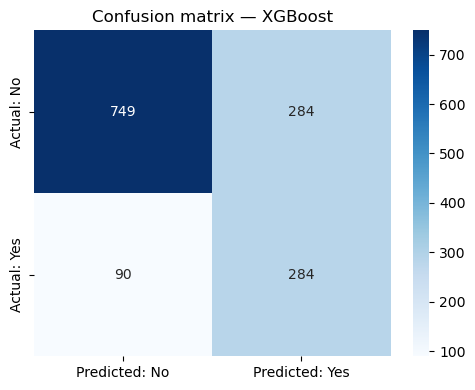


True Negatives  (correctly said 'no churn'): 749
False Positives (wrongly flagged as churn):   284  ← wasted retention calls
False Negatives (missed actual churners):     90  ← customers who slipped away
True Positives  (correctly caught churners):  284  ← business value!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, best['y_pred'])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'],
            ax=ax)
ax.set_title(f'Confusion matrix — {best_name}', fontsize=12)
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

# Translate the numbers into business language
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly said 'no churn'): {tn}")
print(f"False Positives (wrongly flagged as churn):   {fp}  ← wasted retention calls")
print(f"False Negatives (missed actual churners):     {fn}  ← customers who slipped away")
print(f"True Positives  (correctly caught churners):  {tp}  ← business value!")

### Step 8: Save the best model

In [10]:
best_name = 'XGBoost'
best_model = results[best_name]['model']

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

feature_cols = list(X_train.columns)
with open('../models/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print(f"Saved: {best_name}")
print(f"F1: {results[best_name]['F1 Score']}%")
print(f"Recall: {results[best_name]['Recall']}%")
print(f"AUC: {results[best_name]['ROC-AUC']}")

Saved: XGBoost
F1: 60.3%
Recall: 75.9%
AUC: 0.807
